In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import scipy.special as ss
import functools
import xgi
from collections import Counter
m = importlib.import_module(".model", "src")
#mn = importlib.import_module(".model_new", "src")
sem = importlib.import_module(".sem", "src") 
#semn = importlib.import_module(".sem_new", "src") 
em = importlib.import_module(".em", "src")
ll = importlib.import_module(".likelihoods", "src")
from matplotlib import pyplot as plt
import numpy as np
import json

C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\__init__.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\utils\utilities.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


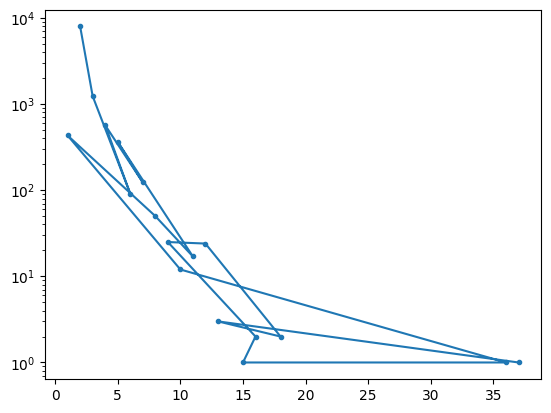

In [8]:
data_name = "email-enron"
H0 = xgi.load_xgi_data(data_name)
H0 = m.GrowingHypergraph(H0)
len(H0.edge_size_sequence())
Counter(H0.edge_size_sequence())

data_dict = Counter(H0.edge_size_sequence())
x = data_dict.keys()
y = data_dict.values()
#plt.scatter(x,y)

plt.semilogy(x,y, marker = ".") 

In [9]:
with open('results/res_{}.json'.format(data_name + "_SEM_new"), 'r') as fp:
    pars = json.load(fp)
timesteps = 10000
H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

added = []

eta = pars["eta"]
gamma = pars["gamma"]
beta = pars["beta"]

for _ in range(timesteps):
    e_ = H.sample_edge(eta, gamma, beta, True)
    #added.append(num)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

This hypergraph has 10002 edges and 725 nodes.


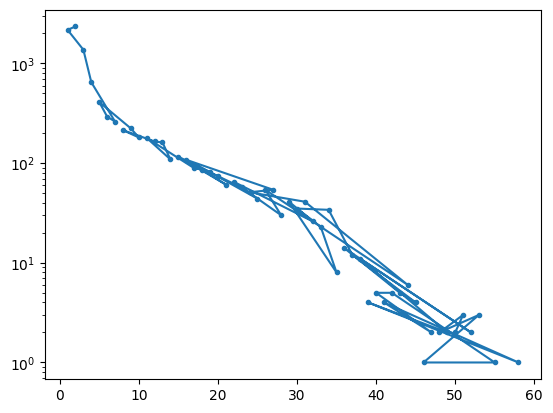

In [10]:
data_dict = Counter(H.edge_size_sequence())
x = data_dict.keys()
y = data_dict.values()
#plt.scatter(x,y)

plt.semilogy(x,y, marker = ".") 